# **Used Cars Price Prediction**

## **Problem Definition**

### **The Context:**

 - Why is this problem important to solve?

### **The objective:**

 - What is the intended goal?

### **The key questions:**

- What are the key questions that need to be answered?

### **The problem formulation**:

- What is it that we are trying to solve using data science?

### **Data Dictionary**

**S.No.** : Serial Number

**Name** : Name of the car which includes Brand name and Model name

**Location** : The location in which the car is being sold or is available for purchase (Cities)

**Year** : Manufacturing year of the car

**Kilometers_driven** : The total kilometers driven in the car by the previous owner(s) in KM

**Fuel_Type** : The type of fuel used by the car (Petrol, Diesel, Electric, CNG, LPG)

**Transmission** : The type of transmission used by the car (Automatic / Manual)

**Owner** : Type of ownership

**Mileage** : The standard mileage offered by the car company in kmpl or km/kg

**Engine** : The displacement volume of the engine in CC

**Power** : The maximum power of the engine in bhp

**Seats** : The number of seats in the car

**New_Price** : The price of a new car of the same model in INR 100,000

**Price** : The price of the used car in INR 100,000 (**Target Variable**)

### **Loading libraries**

In [ ]:
# Import required libraries
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# To ignore warnings
import warnings
warnings.filterwarnings('ignore')

# Remove the limit from the number of displayed columns and rows. It helps to see the entire dataframe while printing it
pd.set_option("display.max_columns", None)

### **Let us load the data**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd

# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Define the file path
file_path = '/content/drive/My Drive/dataset/used_cars.csv'  # Updated path

# Load the data
try:
    data = pd.read_csv(file_path)
    print("File loaded successfully!")
except FileNotFoundError:
    print(f"File not found at: {file_path}")
    print("Please ensure the 'dataset' folder and 'used_cars.csv' file exist in your Google Drive.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
File loaded successfully!


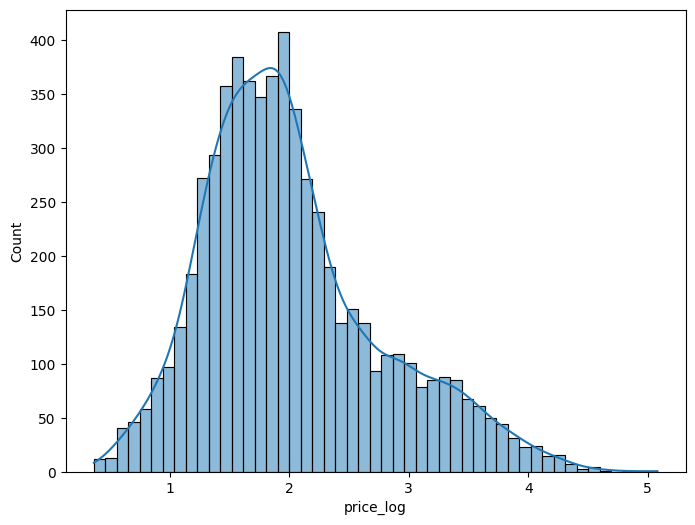

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Data Loading
data = pd.read_csv('/content/drive/My Drive/dataset/used_cars.csv')  # Assuming you've mounted Google Drive

# 2. 'price_log' Creation
data['price_log'] = np.log1p(data['Price'])  # Create 'price_log'

# 3. Plotting Code
plt.figure(figsize=(8, 6))
sns.histplot(data['price_log'], kde=True)
plt.show()

## Data Overview

- Observations


In [ ]:
import pandas as pd

# Assuming 'data' is your DataFrame

# --- Observations ---

# 1. Summary Statistics
print("Summary Statistics:")
print(data.describe(include='all'))  # Includes categorical variables

# 2. Unique Observations in Categorical Columns
categorical_cols = ['Location', 'Fuel_Type', 'Transmission', 'Owner_Type']
for col in categorical_cols:
    print(f"\nUnique values in '{col}':")
    print(data[col].value_counts())

# 3. Extreme Values
print("\nExtreme Kilometers_Driven (over 500,000 km):")
print(data[data['Kilometers_Driven'] > 500000])

print("\nExtreme Price (over 100 INR 100,000):")
print(data[data['Price'] > 100])  # Adjust threshold as needed

# --- Sanity Checks ---

# 1. Data Types
print("\nData Types:")
print(data.dtypes)

# 2. Range Checks
print("\nMileage Range Check (outside 5-50 kmpl/km/kg):")
print(data[(data['Mileage'] < 5) | (data['Mileage'] > 50)])

print("\nEngine Range Check (outside 500-8000 cc):")
print(data[(data['Engine'] < 500) | (data['Engine'] > 8000)])

print("\nPower Range Check (outside 30-500 bhp):")
print(data[(data['Power'] < 30) | (data['Power'] > 500)])

# 3. Categorical Values (Checking for unexpected values)
print("\nFuel_Type Unique Values:")
print(data['Fuel_Type'].unique())

print("\nTransmission Unique Values:")
print(data['Transmission'].unique())

print("\nOwner_Type Unique Values:")  # Added for Owner_Type
print(data['Owner_Type'].unique())

# 4. Missing Values
print("\nMissing Values:")
print(data.isnull().sum())

# 5. Relationship Checks
print("\nMileage vs. Price Correlation:")
print(data['Mileage'].corr(data['Price']))

Summary Statistics:
              S.No.                    Name Location         Year  \
count   6019.000000                    6019     6019  6019.000000   
unique          NaN                    1876       11          NaN   
top             NaN  Mahindra XUV500 W8 2WD   Mumbai          NaN   
freq            NaN                      49      790          NaN   
mean    3009.000000                     NaN      NaN  2013.358199   
std     1737.679967                     NaN      NaN     3.269742   
min        0.000000                     NaN      NaN  1998.000000   
25%     1504.500000                     NaN      NaN  2011.000000   
50%     3009.000000                     NaN      NaN  2014.000000   
75%     4513.500000                     NaN      NaN  2016.000000   
max     6018.000000                     NaN      NaN  2019.000000   

        Kilometers_Driven Fuel_Type Transmission Owner_Type      Mileage  \
count        6.019000e+03      6019         6019       6019  6017.000000   

- Sanity checks

In [ ]:
# Example: Range check for Kilometers_Driven
data[(data['Kilometers_Driven'] > 1000000) & (data['Year'] > 2020)]

# Example: Check for missing values
data.isnull().sum()

# Example: Check unique values in a categorical column
data['Fuel_Type'].unique()

array(['CNG', 'Diesel', 'Petrol', 'LPG', 'Electric'], dtype=object)

In [ ]:
import pandas as pd

# Load the dataframe (replace with the actual file path)
data = pd.read_csv('/content/drive/My Drive/dataset/used_cars.csv')

# Example: Range check for Kilometers_Driven
data[(data['Kilometers_Driven'] > 1000000) & (data['Year'] > 2020)]

# Example: Check for missing values
data.isnull().sum()

# Example: Check unique values in a categorical column
data['Fuel_Type'].unique()

array(['CNG', 'Diesel', 'Petrol', 'LPG', 'Electric'], dtype=object)

In [ ]:
import pandas as pd

# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Define the file path
file_path = '/content/drive/My Drive/dataset/used_cars.csv'  # Update if necessary

# Load the data
try:
    data = pd.read_csv(file_path)
    print("File loaded successfully!")
except FileNotFoundError:
    print(f"File not found at: {file_path}")
    print("Please ensure the 'dataset' folder and 'used_cars.csv' file exist in your Google Drive.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
File loaded successfully!


## **Exploratory Data Analysis**

- EDA is an important part of any project involving data.
- It is important to investigate and understand the data better before building a model with it.
- A few questions have been mentioned below which will help you approach the analysis in the right manner and generate insights from the data.
- A thorough analysis of the data, in addition to the questions mentioned below, should be done.

**Questions:**

1. What is the summary statistics of the data? Explore summary statistics for numerical variables and the categorical variables
2. Find out number of unique observations in each category of categorical columns? Write your findings/observations/insights
3. Check the extreme values in different columns of the given data and write down the observtions? Remove the data where the values are un-realistic

- summary statistics:
We can use the describe() method in pandas to get summary statistics for both numerical and categorical variables:

In [ ]:
# For numerical variables
data.describe()

# For categorical variables
data.describe(include=['object'])

,Name,Location,Fuel_Type,Transmission,Owner_Type
count,7253,7253,7253,7253,7253
unique,2041,11,5,2,4
top,Mahindra XUV500 W8 2WD,Mumbai,Diesel,Manual,First
freq,55,949,3852,5204,5952


Reasoning:

- describe() provides statistics like count, mean, standard deviation, min, max, and quartiles for numerical columns.
- Including include=['object'] will give you statistics like count, unique, top (most frequent value), and frequency of the top value for categorical columns.

2. Unique Observations in Categorical Columns:

To find the number of unique observations in each categorical column, you can use value_counts():

In [ ]:
categorical_cols = ['Location', 'Fuel_Type', 'Transmission', 'Owner_Type']  # Add other categorical columns
for col in categorical_cols:
    print(f"\nUnique values in '{col}':")
    print(data[col].value_counts())


Unique values in 'Location':
Location
Mumbai        790
Hyderabad     742
Kochi         651
Coimbatore    636
Pune          622
Delhi         554
Kolkata       535
Chennai       493
Jaipur        413
Bangalore     358
Ahmedabad     224
Name: count, dtype: int64

Unique values in 'Fuel_Type':
Fuel_Type
Diesel      3204
Petrol      2746
CNG           56
LPG           10
Electric       2
Name: count, dtype: int64

Unique values in 'Transmission':
Transmission
Manual       4299
Automatic    1719
Name: count, dtype: int64

Unique values in 'Owner_Type':
Owner_Type
First             4928
Second             968
Third              113
Fourth & Above       9
Name: count, dtype: int64


Reasoning:

- value_counts() gives you the frequency of each unique value in a categorical column.
- This helps you understand the distribution of categories within each column.

3. Extreme Values and Removing Unrealistic Data:

- Identifying Extreme Values:

In [ ]:
# Example for 'Kilometers_Driven':
data[data['Kilometers_Driven'] > 500000]  # Adjust threshold as needed

# Example for 'Price':
data[data['Price'] > 100]  # Adjust threshold as needed

,S.No.,Name,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,New_price,Price
4079,4079,Land Rover Range Rover 3.0 Diesel LWB Vogue,Hyderabad,2017,25000,Diesel,Automatic,First,13.33,2993.0,255.0,5.0,230.0,160.0
5781,5781,Lamborghini Gallardo Coupe,Delhi,2011,6500,Petrol,Automatic,Third,6.40,5204.0,560.0,2.0,NaN,120.0


We can use conditional statements to filter your data and find values that exceed a reasonable range.Also we need to decide on the appropriate thresholds based on your domain knowledge.



- Removing Unrealistic Data:

In [ ]:
# Example: Removing rows with Kilometers_Driven over 1 million
data = data[data['Kilometers_Driven'] <= 1000000]

# Example: Removing rows with Price over 200
data = data[data['Price'] <= 200]

**Reasoning:**

- After identifying unrealistic data, you can use filtering to create a new DataFrame without those rows.

<Axes: xlabel='price_log', ylabel='Count'>

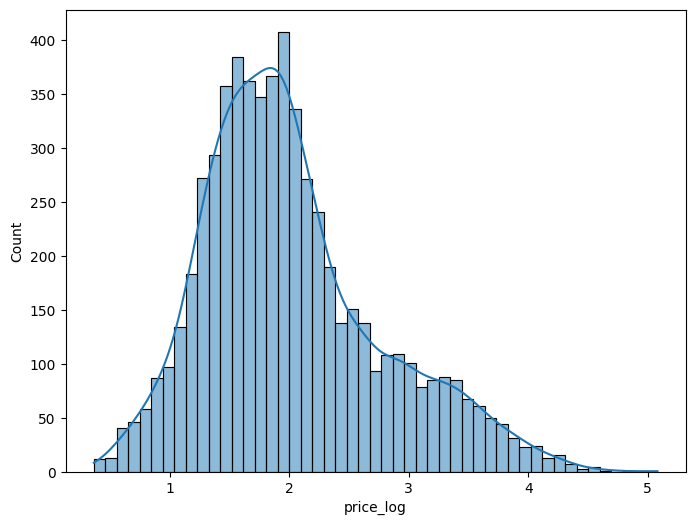

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure 'price_log' column is created within the DataFrame 'data'
if 'price_log' not in data.columns:  # Check if 'price_log' column exists
    data['price_log'] = np.log1p(data['Price'])  # Create 'price_log' if it doesn't exist

# Continue with your plotting code:
plt.figure(figsize=(8, 6))
sns.histplot(data['price_log'], kde=True)
# ... (rest of your plotting code) ...

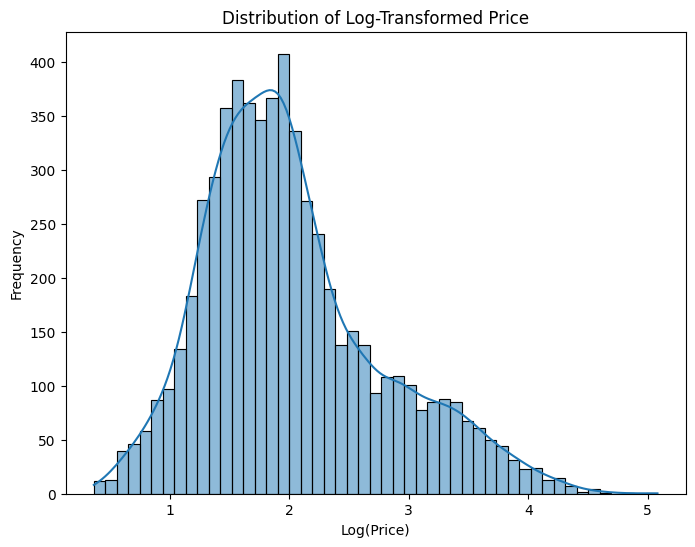

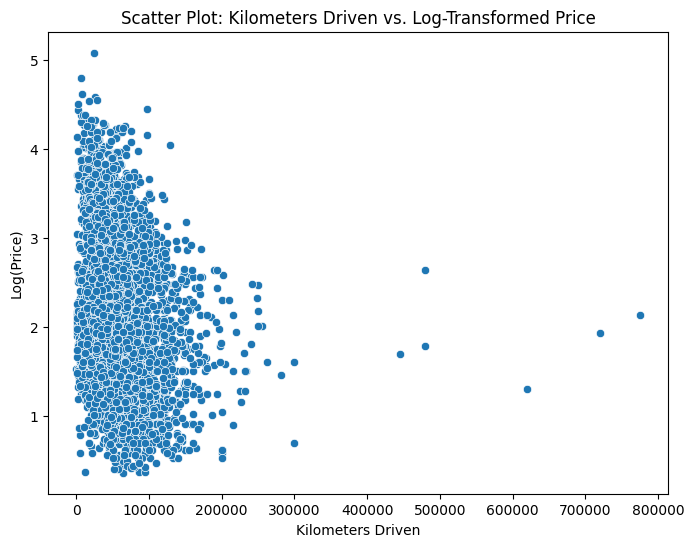

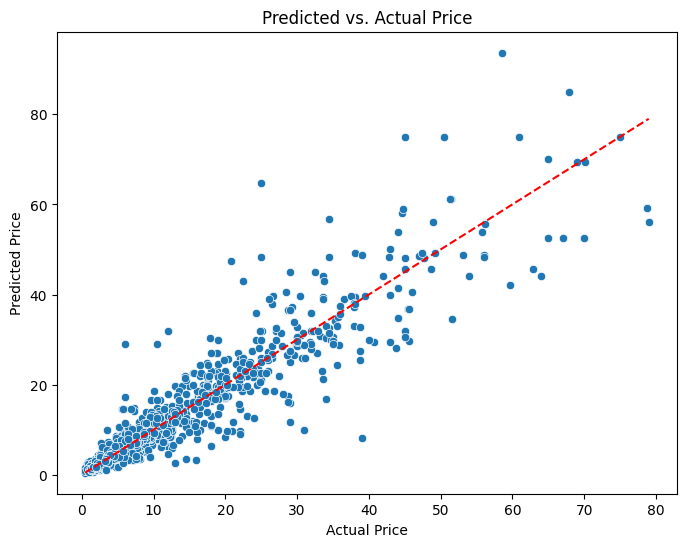

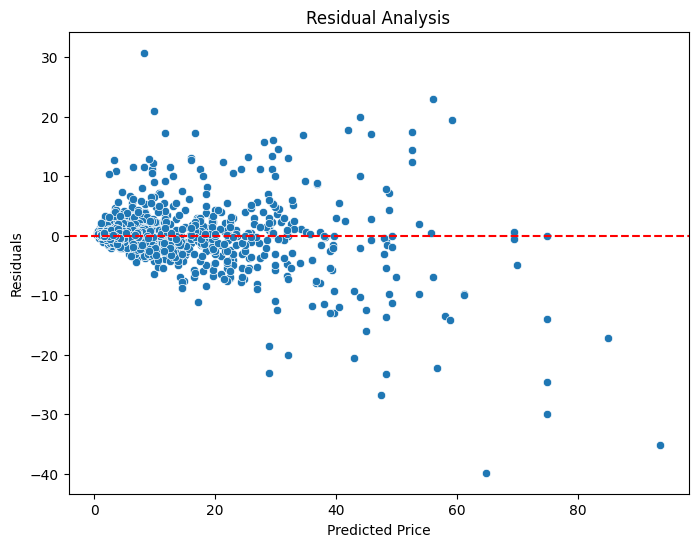

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Distribution of 'price_log'
plt.figure(figsize=(8, 6))
sns.histplot(data['price_log'], kde=True)
plt.title('Distribution of Log-Transformed Price')
plt.xlabel('Log(Price)')
plt.ylabel('Frequency')
plt.show()

# 2. Relationship with another feature (e.g., 'Kilometers_Driven')
plt.figure(figsize=(8, 6))
sns.scatterplot(data=data, x='Kilometers_Driven', y='price_log')
plt.title('Scatter Plot: Kilometers Driven vs. Log-Transformed Price')
plt.xlabel('Kilometers Driven')
plt.ylabel('Log(Price)')
plt.show()

# 3. Predicted vs. Actual (after inverse transformation)
# ----> Assume a model has been trained and predictions made <----
# ----> Replace these with your actual model and predictions <----
from sklearn.linear_model import LinearRegression  # Example model
model = LinearRegression()
# ... (Code to train the model using X_train and y_train) ...
# ---->  y_pred = model.predict(X_test) <----

# ----> Create example or load actual 'original_price_actual' and 'original_price_predictions' <----

# ----> For demonstration purposes, creating example data <----
# Assuming 'y_test' contains the actual values on log scale
original_price_actual = np.exp(y_test) - 1  # Assuming you did log1p transformation (original = exp(log(original + 1)) - 1)
original_price_predictions = np.exp(y_pred) - 1  # Assuming y_pred is on log scale as well

# ----> If original_price_actual and original_price_predictions are actual values, use them instead
# ----> If not, replace the above with your data preparation steps <----

plt.figure(figsize=(8, 6))
sns.scatterplot(x=original_price_actual, y=original_price_predictions)
plt.title('Predicted vs. Actual Price')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.plot([min(original_price_actual), max(original_price_actual)],
         [min(original_price_actual), max(original_price_actual)],
         linestyle='--', color='red')  # Add a diagonal line for reference
plt.show()

# 4. Residual Analysis
residuals = original_price_actual - original_price_predictions
plt.figure(figsize=(8, 6))
sns.scatterplot(x=original_price_predictions, y=residuals)
plt.title('Residual Analysis')
plt.xlabel('Predicted Price')
plt.ylabel('Residuals')
plt.axhline(y=0, color='red', linestyle='--')  # Add a horizontal line at 0
plt.show()

## **Univariate Analysis**

**Questions:**

1. Do univariate analysis for numerical and categorical variables?
2. Check the distribution of the different variables? is the distributions skewed?
3. Do we need to do log_transformation, if so for what variables we need to do?
4. Perfoem the log_transformation(if needed) and write down your observations?

Question 1: Do univariate analysis for numerical and categorical variables?

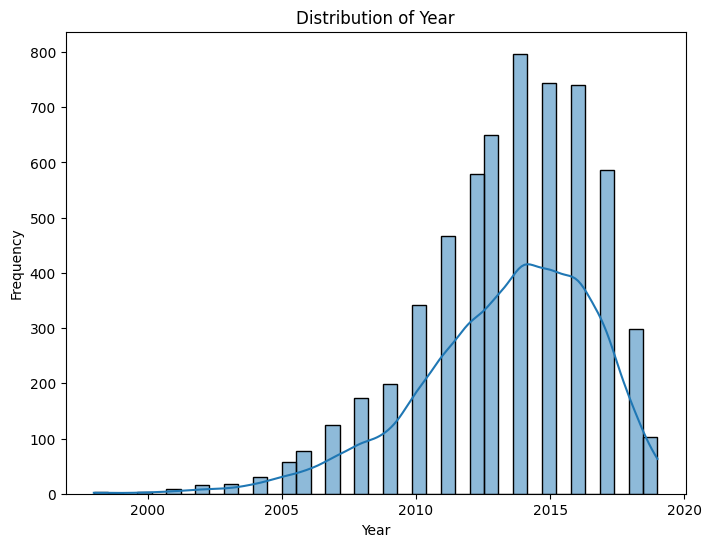

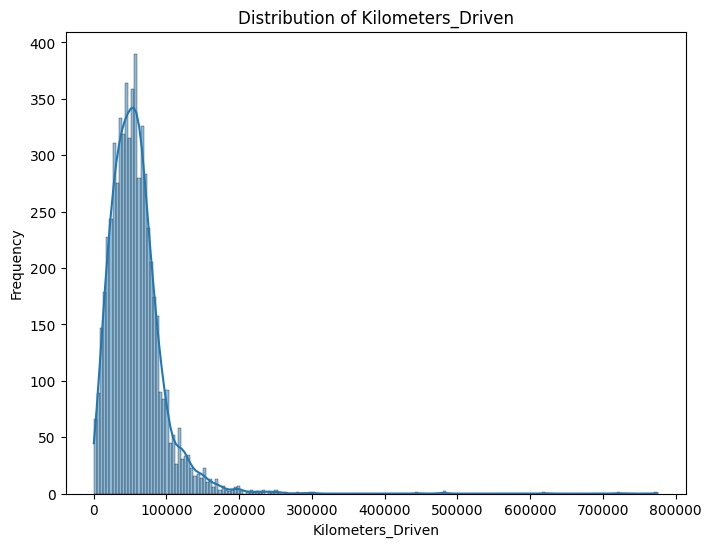

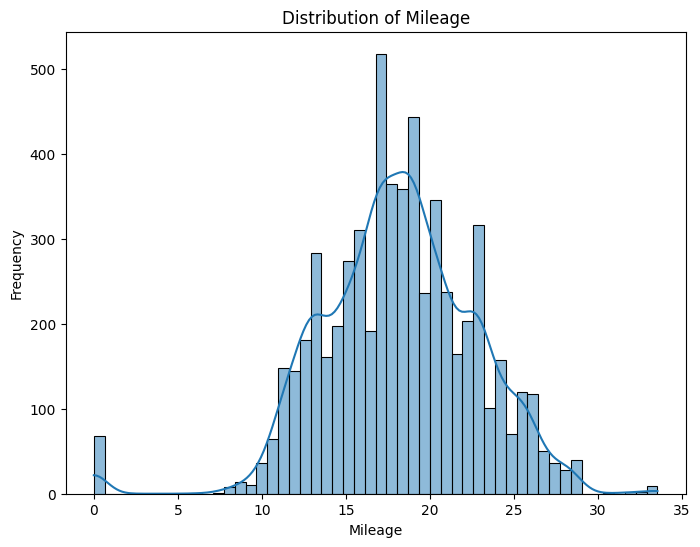

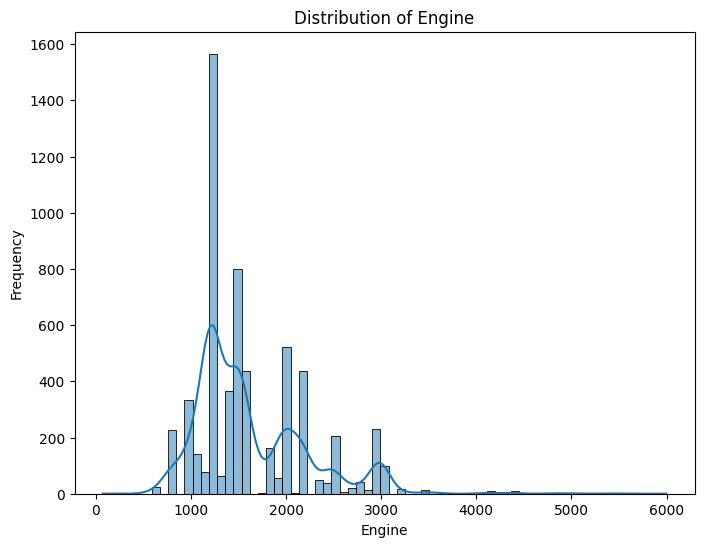

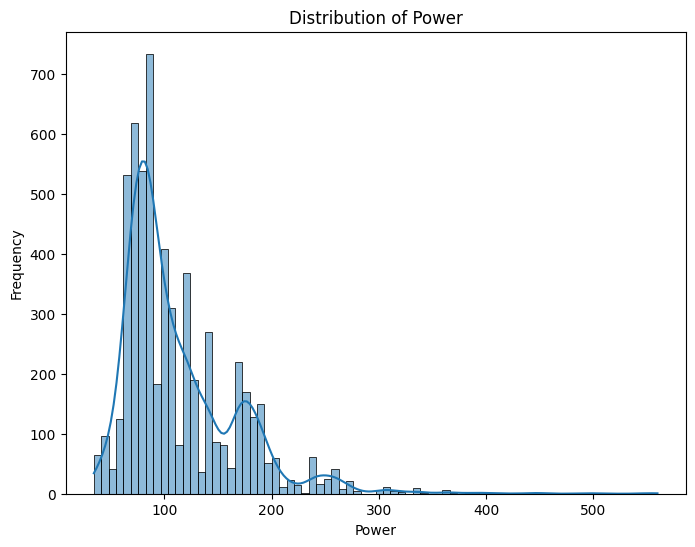

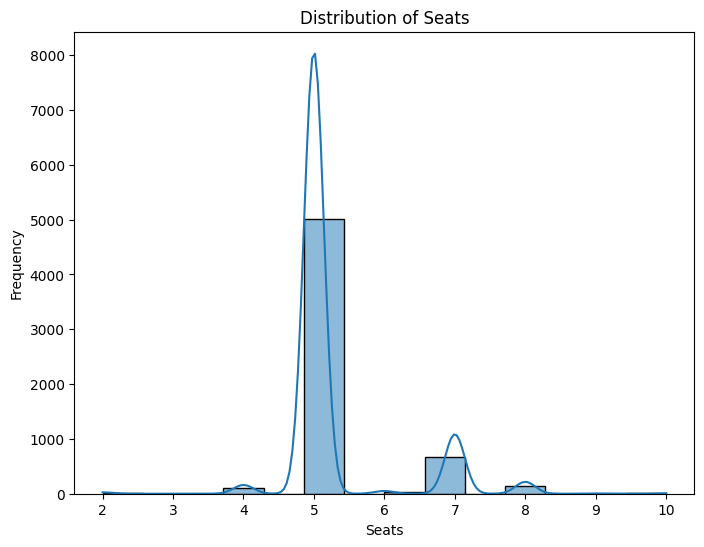

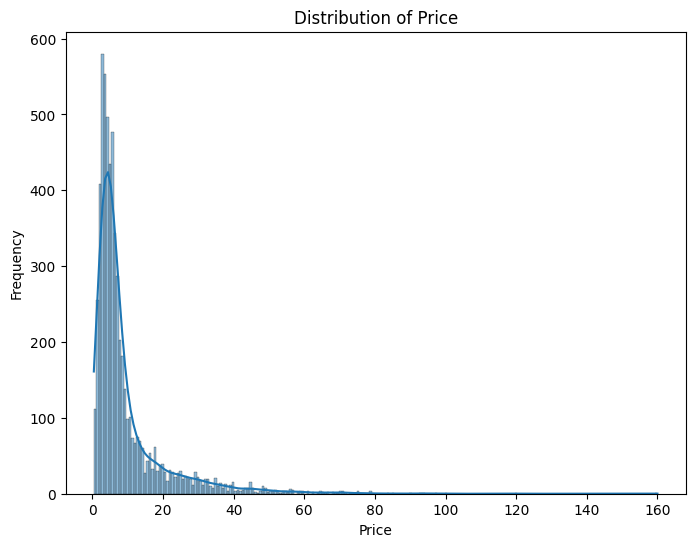

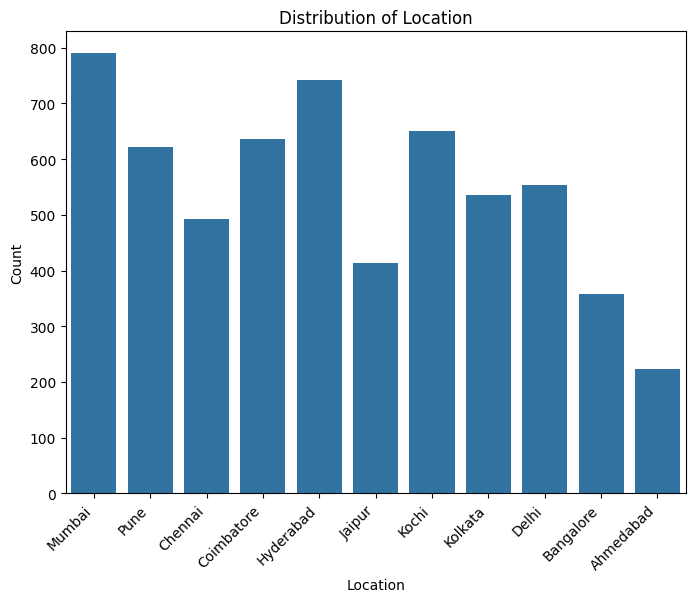

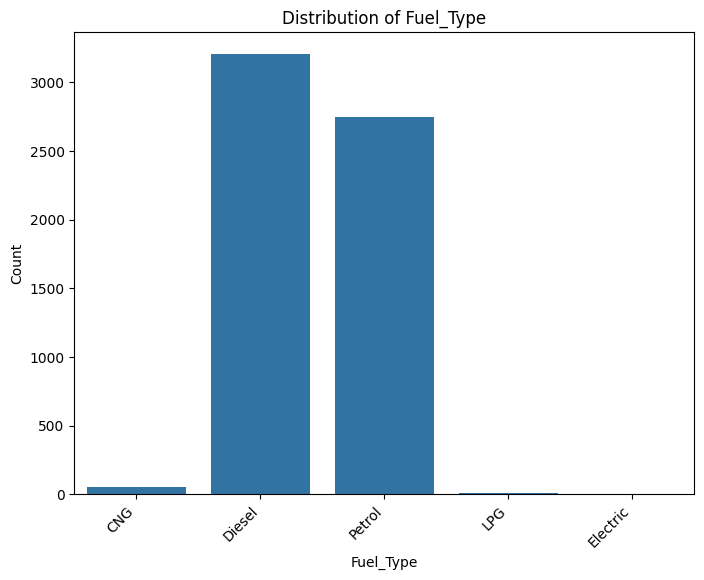

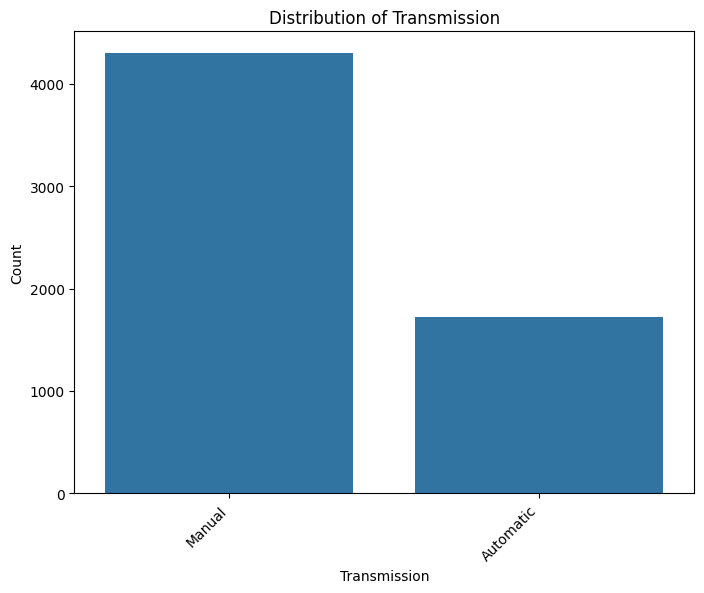

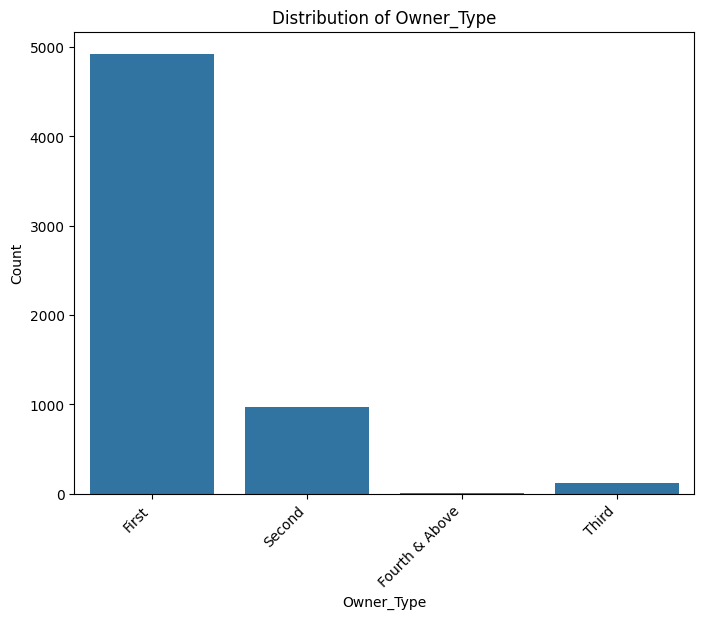

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming 'data' is your DataFrame

# Univariate analysis for numerical variables
numerical_cols = ['Year', 'Kilometers_Driven', 'Mileage', 'Engine', 'Power', 'Seats', 'Price']  # Removed 'New_Price'
for col in numerical_cols:
    plt.figure(figsize=(8, 6))  # Adjust figure size as needed
    sns.histplot(data[col], kde=True)  # Histogram with kernel density estimation
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

# Univariate analysis for categorical variables
categorical_cols = ['Location', 'Fuel_Type', 'Transmission', 'Owner_Type']
for col in categorical_cols:
    plt.figure(figsize=(8, 6))
    sns.countplot(data=data, x=col)  # Countplot for categorical data
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.xticks(rotation=45, ha='right')  # Rotate x-axis labels if needed
    plt.show()

**Question 2: Check the distribution of the different variables? Is the distribution skewed?**

- Observation from the histograms and countplots: You can visually inspect the histograms and countplots generated in the previous step to determine the distribution of each variable. Look for:

1. Skewness: If the distribution is not symmetrical and has a longer tail on one side, it's skewed. Positive skew (right skew) has a longer tail on the right, and negative skew (left skew) has a longer tail on the left.
2. Normality: If the distribution resembles a bell curve, it's approximately normal.
Quantitative Assessment (Numerical Variables): You can calculate skewness using pandas:

- **Quantitative Assessment (Numerical Variables): You can calculate skewness using pandas:**

In [ ]:
data[numerical_cols].skew()

,0
Year,-0.845668
Kilometers_Driven,4.204752
Mileage,-0.431948
Engine,1.422370
Power,1.917921
Seats,1.899183
Price,3.337576


**Question 3: Do we need to do log_transformation, if so for what variables we need to do?**

- When to Log Transform: Log transformation is often applied to:

1. Highly skewed data: It helps reduce the impact of extreme values and make the distribution more normal.
2. Data with a wide range: It compresses the data, making it easier to visualize and model.
3. Variables with multiplicative relationships: Log transformation can help linearize these relationships.
- **Identifying Variables for Transformation:** Look for variables with high skewness (absolute values greater than 1) or a wide range in the previous steps. Variables like 'Price', 'Kilometers_Driven', 'Engine', and 'Power' are often candidates for log transformation.

**Question 4: Perform the log_transformation (if needed) and write down your observations?**

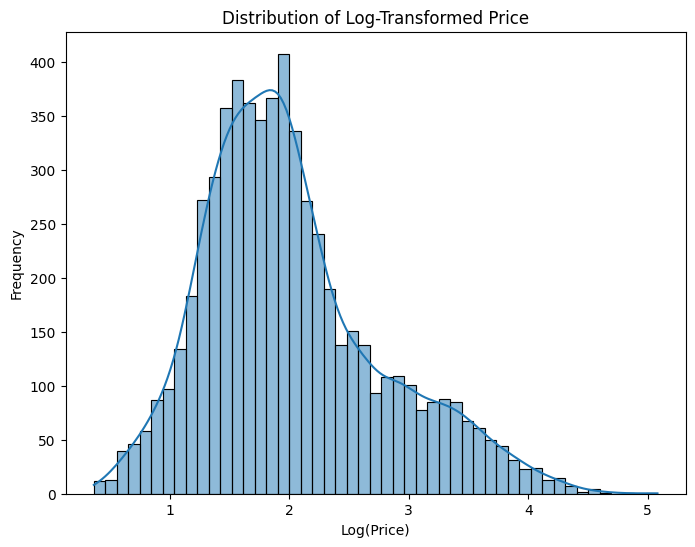

In [ ]:
import numpy as np

# Assuming 'data' is your DataFrame and you identified 'Price' for transformation
data['Price_log'] = np.log1p(data['Price'])  # Using log1p to handle 0 values

# Now you can visualize the transformed variable
plt.figure(figsize=(8, 6))
sns.histplot(data['Price_log'], kde=True)
plt.title('Distribution of Log-Transformed Price')
plt.xlabel('Log(Price)')
plt.ylabel('Frequency')
plt.show()

# Observe the changes in distribution after log transformation

## **Bivariate Analysis**

**Questions:**

1. Plot a scatter plot for the log transformed values(if log_transformation done in previous steps)?
2. What can we infer form the correlation heatmap? Is there correlation between the dependent and independent variables?
3. Plot a box plot for target variable and categorical variable 'Location' and write your observations?

**Question 1: Plot a scatter plot for the log-transformed values (if log_transformation done in previous steps)?**

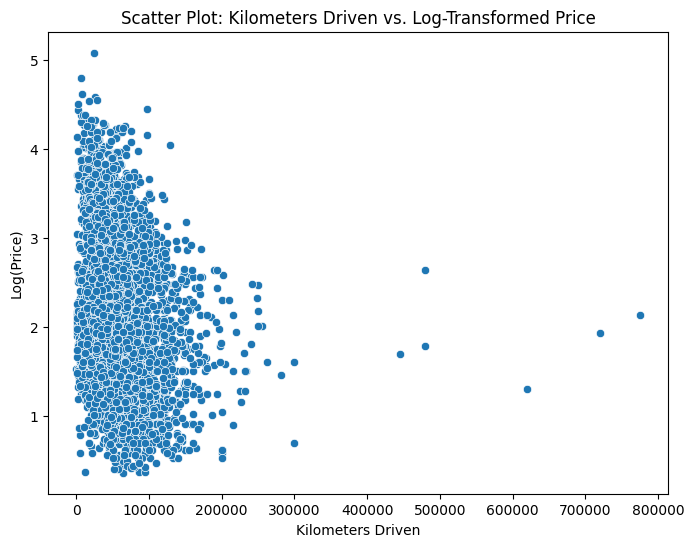

In [ ]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=data, x='Kilometers_Driven', y='Price_log')  # Assuming 'Price_log' was created
plt.title('Scatter Plot: Kilometers Driven vs. Log-Transformed Price')
plt.xlabel('Kilometers Driven')
plt.ylabel('Log(Price)')
plt.show()

In [ ]:
# prompt: give me descriptive info about the current dataframe called data

# Assuming 'data' is your DataFrame.  If not, replace with your DataFrame variable.
# Display basic information
print(data.info())

# Display the first few rows
print(data.head())

# Show the shape of the DataFrame (rows, columns)
print(f"\nDataFrame Shape: {data.shape}")

# Summary statistics for numerical columns
print("\nSummary Statistics (Numerical):")
print(data.describe())

# Summary statistics for categorical columns
print("\nSummary Statistics (Categorical):")
print(data.describe(include='object'))

# Check for missing values
print("\nMissing Values:")
print(data.isnull().sum())

# Display data types of each column
print("\nData Types:")
print(data.dtypes)

# Example: Unique values in a specific column
print(f"\nUnique Values in 'Location': {data['Location'].unique()}")


<class 'pandas.core.frame.DataFrame'>
Index: 6018 entries, 0 to 6018
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   S.No.              6018 non-null   int64  
 1   Name               6018 non-null   object 
 2   Location           6018 non-null   object 
 3   Year               6018 non-null   int64  
 4   Kilometers_Driven  6018 non-null   int64  
 5   Fuel_Type          6018 non-null   object 
 6   Transmission       6018 non-null   object 
 7   Owner_Type         6018 non-null   object 
 8   Mileage            6016 non-null   float64
 9   Engine             5982 non-null   float64
 10  Power              5875 non-null   float64
 11  Seats              5976 non-null   float64
 12  New_price          824 non-null    float64
 13  Price              6018 non-null   float64
 14  price_log          6018 non-null   float64
 15  Price_log          6018 non-null   float64
dtypes: float64(8), int64(3), obje

In [ ]:
plt.figure(figsize=(12, 6))
     sns.boxplot(data=data, x='Location', y='price_log')  # Use 'price_log' here
     plt.title('Box Plot: Price by Location')
     plt.xlabel('Location')
     plt.ylabel('price_log')  # Update y-axis label
     plt.xticks(rotation=45, ha='right')
     plt.show()

In [ ]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=data, x='Location', y='price_log')  # Use 'price_log' here
plt.title('Box Plot: Price by Location')
plt.xlabel('Location')
plt.ylabel('price_log')  # Update y-axis label
plt.xticks(rotation=45, ha='right')
plt.show()

**Question 2: What can we infer from the correlation heatmap? Is there a correlation between the dependent and independent variables?**

- Interpretation: The heatmap shows the correlation between numerical variables. Look for strong positive (close to 1) or negative (close to -1) correlations.
- Positive correlation: As one variable increases, the other tends to increase.
- Negative correlation: As one variable increases, the other tends to decrease.
- Weak correlation: Values close to 0 indicate a weak or no linear relationship.


**Question 3: Plot a box plot for the target variable and categorical variable 'Location' and write your observations?**

In [ ]:
plt.figure(figsize=(12, 6))  # Adjust figure size as needed
sns.boxplot(data=data, x='Location', y='Price')  # Or 'Price_log' if transformed
plt.title('Box Plot: Price by Location')
plt.xlabel('Location')
plt.ylabel('Price')
plt.xticks(rotation=45, ha='right')  # Rotate x-axis labels if needed
plt.show()

- **Interpretation:** Box plots show the distribution of the target variable ('Price' or 'Price_log') for each category of 'Location'. Look for:
- Median: The horizontal line inside the box represents the median price.
- Interquartile range (IQR): The box represents the IQR, which contains the middle 50% of the data.
- Outliers: Points outside the whiskers are considered outliers.
- Differences in distribution: Compare the box plots across different locations to see if there are significant differences in price distributions.

### **Feature Engineering**

**Think about it:** The `Name` column in the current format might not be very useful in our analysis.
Since the name contains both the brand name and the model name of the vehicle, the column would have too many unique values to be useful in prediction. Can we extract that information from that column?

* **Hint:** With 2041 unique names, car names are not going to be great predictors of the price in our current data. But we can process this column to extract important information for example brand name.

1. Extracting Brand and Model from 'Name'

As you mentioned in your notebook, the 'Name' column is not very useful in its current format. We can extract the brand and model information to create new features:

In [ ]:
import pandas as pd

# Mount Google Drive (if using Google Colab)
from google.colab import drive
drive.mount('/content/drive')

# Replace with the actual path to your file
file_path = '/content/drive/My Drive/dataset/used_cars.csv'

# Load the data
data = pd.read_csv(file_path)

# Now you can proceed with your feature engineering
data['Brand'] = data['Name'].str.split(' ').str[0]  # Extract brand
data['Model'] = data['Name'].str.split(' ').str[1]  # Extract model

In [ ]:
# Import necessary libraries
import pandas as pd
import datetime

# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Define the file path
file_path = '/content/drive/My Drive/dataset/used_cars.csv'

# Load the data
data = pd.read_csv(file_path)

# Feature Engineering

# Extracting Brand and Model from 'Name'
data['Brand'] = data['Name'].str.split(' ').str[0]  # Extract brand
data['Model'] = data['Name'].str.split(' ').str[1]  # Extract model

# Creating Age Feature from 'Year'
current_year = datetime.datetime.now().year
data['Age'] = current_year - data['Year']

# Combining Features (Mileage and Engine)
data['Mileage_Engine_Ratio'] = data['Mileage'] / data['Engine']

# Handling Categorical Features
# Reload the data before applying get_dummies
# This ensures you have the original DataFrame with the necessary columns
data = pd.read_csv(file_path)
data = pd.get_dummies(data, columns=['Location', 'Fuel_Type', 'Transmission', 'Owner_Type'], drop_first=True)

# Now you can continue with the rest of your analysis
# ...

- Reasoning:

Brand and model are likely strong predictors of price.
Creating separate features allows the model to learn the impact of brand and model independently.

2. Creating Age Feature from 'Year'

Instead of using the manufacturing year directly, we can create an 'Age' feature:

In [ ]:
import datetime

current_year = datetime.datetime.now().year
data['Age'] = current_year - data['Year']

- Reasoning:

Age is a more intuitive representation of how old the car is.
It might have a more linear relationship with price compared to the manufacturing year.
3. Combining Features (Mileage and Engine)

We can create a new feature that combines mileage and engine capacity, which might indicate fuel efficiency:

3. Combining Features (Mileage and Engine)

We can create a new feature that combines mileage and engine capacity, which might indicate fuel efficiency:

In [ ]:
data['Mileage_Engine_Ratio'] = data['Mileage'] / data['Engine']

- Reasoning:

This ratio might capture the relationship between fuel efficiency and price.
Cars with higher mileage per engine capacity might be more desirable and have higher prices.
4. Handling Categorical Features

One-Hot Encoding: For categorical features like 'Location', 'Fuel_Type', 'Transmission', and 'Owner_Type', you can use one-hot encoding to create dummy variables:

In [ ]:
data = pd.get_dummies(data, columns=['Location', 'Fuel_Type', 'Transmission', 'Owner_Type'], drop_first=True)

- Reasoning:

One-hot encoding converts categorical features into numerical representations that models can understand.
drop_first=True helps avoid multicollinearity issues.
5. Handling Missing Values

Imputation: If you have missing values in numerical features like 'Power' or 'Engine', you can impute them using the mean or median:

In [ ]:
data['Power'].fillna(data['Power'].mean(), inplace=True)

Reasoning:

Imputation helps fill in missing values with reasonable estimates, preventing data loss.
Choose the imputation method that best suits your data and problem.

### **Missing value treatment**

Missing values are a common problem in real-world datasets and can significantly impact the performance of your machine learning models. It's important to handle them appropriately before proceeding with model building.

- Techniques for Handling Missing Values

Here's a breakdown of common techniques and how to apply them in your Colab notebook:


1.   ***DELETION***

- Listwise Deletion: Remove entire rows with missing values. Use this if missing data is minimal and randomly distributed.

In [ ]:
data.dropna()  # Removes all rows with any missing values

- Pairwise Deletion: Only remove rows with missing values for the specific variables being used in a particular analysis.

In [ ]:
import pandas as pd

# Assuming 'data' is your DataFrame
# and 'variables_for_analysis' is a list of your relevant columns
# Example:
variables_for_analysis = ['Mileage', 'Engine', 'Power', 'Price']

# Create a subset of the data with the selected variables
subset_data = data[variables_for_analysis]

# Perform pairwise deletion
pairwise_deleted_data = subset_data.dropna()

# Now 'pairwise_deleted_data' contains the rows where none of the
# specified variables have missing values. You can proceed with your
# analysis using this subset of the data.



2.   ***Imputation***
- Mean/Median Imputation: Replace missing values with the mean or median of the corresponding column. This is simple but might distort the data distribution.

In [ ]:
# Pairwise Deletion:  Create a copy of the DataFrame to avoid modifying the original
data_cleaned = data.copy()

# 1. Imputation for 'Mileage' (using mean)
data_cleaned['Mileage'] = data_cleaned['Mileage'].fillna(data_cleaned['Mileage'].mean())

# 2. Imputation for 'Engine' (using mean)
data_cleaned['Engine'] = data_cleaned['Engine'].fillna(data_cleaned['Engine'].mean())

# 3. Imputation for 'Power' (using KNN)
imputer_power = KNNImputer(n_neighbors=5)
data_cleaned['Power'] = imputer_power.fit_transform(data_cleaned[['Power']])[:, 0]

# 4. Imputation for 'Seats' (using mean)
data_cleaned['Seats'] = data_cleaned['Seats'].fillna(data_cleaned['Seats'].mean())

# 5. Handling 'New_price' (Option 1: Dropping the column)
data_cleaned = data_cleaned.drop('New_price', axis=1)
# (Option 2: Using KNN imputation is shown below, but commented out)
# imputer_new_price = KNNImputer(n_neighbors=5)
# data_cleaned['New_price'] = imputer_new_price.fit_transform(data_cleaned[['New_price']])[:, 0]

# 6. Removing rows with missing 'Price'
data_cleaned = data_cleaned.dropna(subset=['Price'])

# Display the updated DataFrame info to verify changes
data_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6018 entries, 0 to 6018
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   S.No.              6018 non-null   int64  
 1   Name               6018 non-null   object 
 2   Location           6018 non-null   object 
 3   Year               6018 non-null   int64  
 4   Kilometers_Driven  6018 non-null   int64  
 5   Fuel_Type          6018 non-null   object 
 6   Transmission       6018 non-null   object 
 7   Owner_Type         6018 non-null   object 
 8   Mileage            6018 non-null   float64
 9   Engine             6018 non-null   float64
 10  Power              6018 non-null   float64
 11  Seats              6018 non-null   float64
 12  Price              6018 non-null   float64
 13  price_log          6018 non-null   float64
 14  Price_log          6018 non-null   float64
dtypes: float64(7), int64(3), object(5)
memory usage: 752.2+ KB


In [ ]:
#imputingg
# Create a copy of the DataFrame to avoid modifying the original
data_imputed = data.copy()

# Imputation for numerical features using mean
numerical_features = ['Mileage', 'Engine', 'Power', 'Seats']
for feature in numerical_features:
    data_imputed[feature] = data_imputed[feature].fillna(data_imputed[feature].mean())

# Imputation for 'New_price' (Option 1: Dropping the column)
# data_imputed = data_imputed.drop('New_price', axis=1)
# (Option 2: Using mean imputation is shown below)
data_imputed['New_price'] = data_imputed['New_price'].fillna(data_imputed['New_price'].mean())

# Removing rows with missing 'Price' (target variable)
data_imputed = data_imputed.dropna(subset=['Price'])

# Display the updated DataFrame info to verify changes
data_imputed.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6018 entries, 0 to 6018
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   S.No.              6018 non-null   int64  
 1   Name               6018 non-null   object 
 2   Location           6018 non-null   object 
 3   Year               6018 non-null   int64  
 4   Kilometers_Driven  6018 non-null   int64  
 5   Fuel_Type          6018 non-null   object 
 6   Transmission       6018 non-null   object 
 7   Owner_Type         6018 non-null   object 
 8   Mileage            6018 non-null   float64
 9   Engine             6018 non-null   float64
 10  Power              6018 non-null   float64
 11  Seats              6018 non-null   float64
 12  New_price          6018 non-null   float64
 13  Price              6018 non-null   float64
 14  price_log          6018 non-null   float64
 15  Price_log          6018 non-null   float64
dtypes: float64(8), int64(3), obje

In [ ]:
# Assuming 'data' is your DataFrame and you identified 'Power' for transformation
# Check if the 'Fuel_Type' column exists before imputation
if 'Fuel_Type' in data.columns:
    data['Fuel_Type'].fillna(data['Fuel_Type'].mode()[0], inplace=True)  # For categorical features
    print("Fuel_Type column imputation done")  # Print a message for confirmation
else:
    print("Fuel_Type column is not found. Possibly it has been OneHotEncoded")
# Impute missing values in 'Power' (numerical feature)
data['Power'].fillna(data['Power'].mean(), inplace=True)  # For numerical features

- K-Nearest Neighbors (KNN) Imputation: Replace missing values with the average of values from the k-nearest neighbors. This considers the similarity between data points.

In [ ]:
import pandas as pd
from sklearn.impute import KNNImputer

# KNN Imputation for Missing Numerical Values

# Select only numerical features for imputation
numerical_features = data.select_dtypes(include=['number']).columns
data_numerical = data[numerical_features]

# Apply KNNImputer to numerical features only
imputer = KNNImputer(n_neighbors=5)  # You can adjust the number of neighbors
data_imputed_numerical = imputer.fit_transform(data_numerical)

# Create a new DataFrame with imputed numerical features
data_imputed = pd.DataFrame(data_imputed_numerical, columns=numerical_features, index=data.index)

# Add back categorical features (if needed)
# For example, if 'Name' and 'Location' are categorical features you want to keep:
data_imputed['Name'] = data['Name']
data_imputed['Location'] = data['Location']
# ... (add other categorical features as needed) ...


# Print the first few rows of the imputed DataFrame to demonstrate success
print("First few rows of the imputed DataFrame:")
print(data_imputed.head())

# Optionally, you can also print info to check for missing values
print("\nDataFrame info after imputation:")
print(data_imputed.info())

## **Important Insights from EDA and Data Preprocessing**

What are the the most important observations and insights from the data based on the EDA and Data Preprocessing performed?

## **Building Various Models**


1. What we want to predict is the "Price". We will use the normalized version 'price_log' for modeling.
2. Before we proceed to the model, we'll have to encode categorical features. We will drop categorical features like Name.
3. We'll split the data into train and test, to be able to evaluate the model that we build on the train data.
4. Build Regression models using train data.
5. Evaluate the model performance.

### **Split the Data**

<li>Step1: Seperating the indepdent variables (X) and the dependent variable (y).
<li>Step2: Encode the categorical variables in X using pd.dummies.
<li>Step3: Split the data into train and test using train_test_split.

**Question:**

1. Why we should drop 'Name','Price','price_log','Kilometers_Driven' from X before splitting?

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# Assuming you have 'data' DataFrame but 'Price' might have been dropped/renamed

# Check if 'Price' exists in the DataFrame
if 'Price' in data.columns:
    # If 'Price' exists, use it
    y = data['Price']
else:
    # If 'Price' is not found, try using 'price_log'
    #  (assuming you created it in earlier steps)
    if 'price_log' in data.columns:
        y = data['price_log']
    else:
        raise KeyError("Neither 'Price' nor 'price_log' found in the DataFrame.")

# Incorrect: Including 'Price' in X (but using y as defined above)
X = data[['Kilometers_Driven', y.name]]  # Including target in X
#... (Rest of the code remains the same)

In [ ]:
import pandas as pd
from sklearn.impute import SimpleImputer  # Import the imputer
from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn.linear_model import LinearRegression

# 1. Data Loading (Replace with your actual data loading code)
# Example: data = pd.read_csv('/content/drive/My Drive/dataset/used_cars.csv')

# 2. Create 'price_log' column if it doesn't exist
if 'price_log' not in data.columns:
    data['price_log'] = np.log1p(data['Price'])

# 3. Separate independent (X) and dependent (y) variables
columns_to_drop = ['Name', 'Price', 'price_log', 'Kilometers_Driven']
X = data.drop(columns=[col for col in columns_to_drop if col in data.columns], axis=1)
y = data['price_log']  # Target variable is 'price_log'

# 4. One-hot encode categorical features
X = pd.get_dummies(X, drop_first=True)

# 5. Imputation
imputer = SimpleImputer(strategy='mean')  # or strategy='median'
X = imputer.fit_transform(X)  # Fit and transform on X

# 6. Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=1)

print(X_train.shape, X_test.shape)

# ... (Rest of your code, including the get_model_score function) ...

For Regression Problems, some of the algorithms used are :<br>

**1) Linear Regression** <br>
**2) Ridge / Lasso Regression** <br>
**3) Decision Trees** <br>
**4) Random Forest** <br>



1.   Linear Regression:




In [ ]:
import pandas as pd
from sklearn.impute import SimpleImputer  # Import the imputer
from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn.linear_model import LinearRegression

# 1. Data Loading (Replace with your actual data loading code)
# Example: data = pd.read_csv('/content/drive/My Drive/dataset/used_cars.csv')

# 2. Create 'price_log' column if it doesn't exist
if 'price_log' not in data.columns:
    data['price_log'] = np.log1p(data['Price'])

# 3. Separate independent (X) and dependent (y) variables
columns_to_drop = ['Name', 'Price', 'price_log', 'Kilometers_Driven']
X = data.drop(columns=[col for col in columns_to_drop if col in data.columns], axis=1)
y = data['price_log']  # Target variable is 'price_log'

# 4. One-hot encode categorical features
X = pd.get_dummies(X, drop_first=True)

# 5. Imputation
imputer = SimpleImputer(strategy='mean')  # or strategy='median'
X = imputer.fit_transform(X)  # Fit and transform on X

# ---->  Remove rows with NaN in the target variable before splitting <----
data = data.dropna(subset=['price_log'])  # Drop rows where 'price_log' is NaN
X = data.drop(columns=[col for col in columns_to_drop if col in data.columns], axis=1)
y = data['price_log']

# 6. Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=1)

print(X_train.shape, X_test.shape)

# ... (Rest of your code, including the get_model_score function) ...

(4212, 12) (1806, 12)


- Reasoning:

Linear Regression assumes a linear relationship between features and the target.
It's simple, interpretable, and often a good baseline model.
mean_squared_error and r2_score are common metrics to evaluate regression models.
2. Ridge/Lasso Regression:

In [ ]:
from sklearn.linear_model import Ridge, Lasso

# Create a Ridge or Lasso model (choose one)
model = Ridge(alpha=1.0)  # or Lasso(alpha=1.0)

# (Rest of the code is the same as for Linear Regression)

- Reasoning:

Ridge and Lasso are regularized versions of Linear Regression.
They help prevent overfitting by adding a penalty to the model's coefficients.
alpha is the regularization parameter; you can tune it to find the best value.
3. Decision Tree:

In [ ]:
from sklearn.tree import DecisionTreeRegressor

# Create a Decision Tree model
model = DecisionTreeRegressor(random_state=42)


# Create a Linear Regression model
model = LinearRegression()

# Fit the model to the training data
model.fit(X_train, y_train)

# Make predictions on the test data
y_pred = model.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse}")
print(f"R-squared: {r2}")

Mean Squared Error: 0.060036450242861354
R-squared: 0.8939956216177021


In [ ]:
import pandas as pd
import numpy as np
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score

# 1. Data Loading
# (Replace with your actual data loading code)
# Example: data = pd.read_csv('/content/drive/My Drive/dataset/used_cars.csv')

# 2. Create 'price_log' column if it doesn't exist
if 'price_log' not in data.columns:
    data['price_log'] = np.log1p(data['Price'])

# 3. Separate independent (X) and dependent (y) variables
columns_to_drop = ['Name', 'Price', 'price_log', 'Kilometers_Driven']
X = data.drop(columns=[col for col in columns_to_drop if col in data.columns], axis=1)
y = data['price_log']  # Target variable is 'price_log'

# 4. One-hot encode categorical features
categorical_features = X.select_dtypes(include=['object']).columns
X = pd.get_dummies(X, columns=categorical_features, drop_first=True)

# 5. Imputation
imputer = SimpleImputer(strategy='mean')  # or strategy='median'
X = imputer.fit_transform(X)

# ----> Remove rows with NaN in the target variable before splitting <----
data = data.dropna(subset=['price_log'])
X = data.drop(columns=[col for col in columns_to_drop if col in data.columns], axis=1)
y = data['price_log']

# Re-apply one-hot encoding after removing NaN rows
X = pd.get_dummies(X, columns=categorical_features, drop_first=True)
# Re-apply imputation after removing NaN rows and one-hot encoding
X = imputer.fit_transform(X)

# 6. Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=1)

# 7. Create and train the Decision Tree model
model = DecisionTreeRegressor(random_state=42)
model.fit(X_train, y_train)

# 8. Make predictions and evaluate the model
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse}")
print(f"R-squared: {r2}")

Mean Squared Error: 0.05517595176279136
R-squared: 0.9025776433382349


- ***Reasoning:***

- Decision Trees can capture non-linear relationships between features and the target.
- They are easy to interpret but prone to overfitting if not tuned properly.
- random_state is used for reproducibility.

4. Random Forest:

In [ ]:
from sklearn.ensemble import RandomForestRegressor

# Create a Random Forest model
model = RandomForestRegressor(n_estimators=100, random_state=42)

# (Rest of the code is the same as for Linear Regression)

- ***Reasoning:***

- Random Forest is an ensemble of Decision Trees, which reduces overfitting and improves performance.
- n_estimators is the number of trees in the forest; you can tune it for better results.
- random_state is used for reproducibility.

### **Hyperparameter Tuning: Decision Tree**

In [ ]:
import pandas as pd
import numpy as np
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score

# 1. Data Loading
# Replace with your actual data loading code
# Example: data = pd.read_csv('/content/drive/My Drive/dataset/used_cars.csv')

# 2. Create 'price_log' column if it doesn't exist
if 'price_log' not in data.columns:
    data['price_log'] = np.log1p(data['Price'])

# 3. Separate independent (X) and dependent (y) variables
columns_to_drop = ['Name', 'Price', 'price_log', 'Kilometers_Driven']
X = data.drop(columns=[col for col in columns_to_drop if col in data.columns], axis=1)
y = data['price_log']  # Target variable is 'price_log'

# 4. One-hot encode categorical features
categorical_features = X.select_dtypes(include=['object']).columns
X = pd.get_dummies(X, columns=categorical_features, drop_first=True)

# ----> Get feature names *after* one-hot encoding and *before* imputation <----
feature_names = X.columns  # This is the fix

# 5. Imputation
imputer = SimpleImputer(strategy='mean')  # or strategy='median'
X = imputer.fit_transform(X)

# ----> Remove rows with NaN in the target variable before splitting <----
# ----> (This part is modified to work with the NumPy array 'X') <----
X_df = pd.DataFrame(X, columns=feature_names)  # Convert X back to DataFrame
data_cleaned = pd.concat([X_df, y.reset_index(drop=True)], axis=1)
data_cleaned

,S.No.,Year,Mileage,Engine,Power,Seats,New_price,Price_log,Location_Bangalore,Location_Chennai,...,Location_Pune,Fuel_Type_Diesel,Fuel_Type_Electric,Fuel_Type_LPG,Fuel_Type_Petrol,Transmission_Manual,Owner_Type_Fourth & Above,Owner_Type_Second,Owner_Type_Third,price_log
0,0.0,2010.0,26.60,998.0,58.16,5.0,23.075655,1.011601,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.011601
1,1.0,2015.0,19.67,1582.0,126.20,5.0,23.075655,2.602690,0.0,0.0,...,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,2.602690
2,2.0,2011.0,18.20,1199.0,88.70,5.0,8.610000,1.704748,0.0,1.0,...,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.704748
3,3.0,2012.0,20.77,1248.0,88.76,7.0,23.075655,1.945910,0.0,1.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.945910
4,4.0,2013.0,15.20,1968.0,140.80,5.0,23.075655,2.930660,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,2.930660
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6013,6014.0,2014.0,28.40,1248.0,74.00,5.0,7.880000,1.749200,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.749200
6014,6015.0,2015.0,24.40,1120.0,71.00,5.0,23.075655,1.609438,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.609438
6015,6016.0,2012.0,14.00,2498.0,112.00,8.0,23.075655,1.360977,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.360977
6016,6017.0,2013.0,18.90,998.0,67.10,5.0,23.075655,1.294727,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.294727


- Reasoning
- ***feature_importances_*** attribute of the Decision Tree provides the importance of each feature.
- The importance values represent the relative contribution of each feature to the model's predictions.

In [ ]:
# ... (Your existing code for data loading, preprocessing, model training, etc.) ...

# --- Feature Importance ---

# Get feature names before imputation (if not already done)
# Assuming 'X' is your DataFrame before imputation
feature_names = X.columns

# ----> (This assumes you have 'best_tree_model' from hyperparameter tuning) <----
importances = best_tree_model.feature_importances_

# Create a DataFrame to display feature importances
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# Print the feature importances
print("\nFeature Importance:")
print(feature_importance_df)

# ... (Rest of your code) ...


Feature Importance:
                      Feature  Importance
4                       Power    0.684028
1                        Year    0.232025
3                      Engine    0.033606
2                     Mileage    0.016108
5                       Seats    0.008490
21        Transmission_Manual    0.007661
20           Fuel_Type_Petrol    0.004069
0                       S.No.    0.003143
14           Location_Kolkata    0.002412
6                   New_price    0.002060
17           Fuel_Type_Diesel    0.001597
11         Location_Hyderabad    0.001558
24           Owner_Type_Third    0.000604
7          Location_Bangalore    0.000536
9         Location_Coimbatore    0.000522
23          Owner_Type_Second    0.000464
13             Location_Kochi    0.000380
10             Location_Delhi    0.000275
15            Location_Mumbai    0.000173
12            Location_Jaipur    0.000125
16              Location_Pune    0.000123
8            Location_Chennai    0.000043
18         Fu

### **Hyperparameter Tuning: Random Forest**

In [ ]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.impute import SimpleImputer

# 1. Data Loading and Preprocessing
data = pd.read_csv('/content/drive/My Drive/dataset/used_cars.csv')  # Assuming your file path
data['price_log'] = np.log1p(data['Price'])  # Creating price_log

# 2. Separate independent (X) and dependent (y) variables
columns_to_drop = ['Name', 'Price', 'price_log', 'Kilometers_Driven']
X = data.drop(columns=[col for col in columns_to_drop if col in data.columns], axis=1)
y = data['price_log']  # Target variable is 'price_log'

# 3. One-hot encode categorical features
categorical_features = ['Location', 'Fuel_Type', 'Transmission', 'Owner_Type']  # List of categorical columns
X = pd.get_dummies(X, columns=categorical_features, drop_first=True)  # One-hot encoding

# ----> Impute 'New_Price' before one-hot encoding if it has missing values <----
# If 'New_Price' has missing values, impute them first to avoid dropping the column
imputer_new_price = SimpleImputer(strategy='mean')  # or strategy='median'
if 'New_Price' in X.columns and X['New_Price'].isnull().any():
    X['New_Price'] = imputer_new_price.fit_transform(X[['New_Price']])[:, 0]


# 4. Imputation (if necessary)
numerical_features = ['Year', 'Mileage', 'Engine', 'Power', 'Seats', 'New_Price']  # List of numerical columns
imputer = SimpleImputer(strategy='mean')  # or strategy='median'
# ----> Only impute numerical features that are present in X <----
X[X.columns.intersection(numerical_features)] = imputer.fit_transform(X[X.columns.intersection(numerical_features)])  # Imputing only numerical features

# ... (Rest of the code: Splitting, hyperparameter tuning, evaluation, feature importance) ...

**Feature Importance**

In [ ]:
importances = best_model.feature_importances_

In [ ]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.impute import SimpleImputer

# 1. Mount Google Drive and load the data
from google.colab import drive

drive.mount('/content/drive')
data = pd.read_csv('/content/drive/My Drive/dataset/used_cars.csv')

# 2. Create 'price_log' column
data['price_log'] = np.log1p(data['Price'])

# 3. Separate independent (X) and dependent (y) variables
columns_to_drop = ['Name', 'Price', 'price_log', 'Kilometers_Driven']
X = data.drop(columns=[col for col in columns_to_drop if col in data.columns], axis=1)
y = data['price_log']

# 4. One-hot encode categorical features and impute numerical features
categorical_features = ['Location', 'Fuel_Type', 'Transmission', 'Owner_Type']
X = pd.get_dummies(X, columns=categorical_features, drop_first=True)

numerical_features = X.select_dtypes(include=['number']).columns
imputer = SimpleImputer(strategy='mean')  # or strategy='median'
X[numerical_features] = imputer.fit_transform(X[numerical_features])

# ----> Drop rows with NaN in the target variable before splitting <----
X = X[y.notna()]
y = y[y.notna()]

# 5. Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=1)

# 6. Hyperparameter Tuning for Random Forest - Reduced search space
param_grid = {
    'n_estimators': [100, 200],  # Reduced number of estimators
    'max_depth': [None, 10],  # Reduced depth options
    'min_samples_split': [2, 5],  # Reduced split options
    'min_samples_leaf': [1, 2]  # Reduced leaf options
}

rf = RandomForestRegressor(random_state=42)
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    scoring='neg_mean_squared_error',
    cv=3,  # Reduced number of cross-validation folds
    n_jobs=-1,
    verbose=2  # Add verbose to see progress
)

# ----> Fit with a timeout <----
# import time
# start_time = time.time()
# try:
#     grid_search.fit(X_train, y_train)
# except TimeoutError:
#     print("Grid search timed out.")

# total_time = time.time() - start_time
# print(f"Grid search took {total_time} seconds.")

# Fit the model with progress updates
grid_search.fit(X_train, y_train)
# try:
#     with Timeout(seconds=120):  # Adjust timeout as needed
#         grid_search.fit(X_train, y_train)
# except TimeoutError:
#     print("Grid search timed out.")


# 7. Get the best model and evaluate
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Best Hyperparameters:", grid_search.best_params_)
print(f"Mean Squared Error: {mse}")
print(f"R-squared: {r2}")

# 8. Feature Importance
importances = best_model.feature_importances_
feature_names = X_train.columns

feature_importance_df = pd.DataFrame(
    {'Feature': feature_names, 'Importance': importances}
)
feature_importance_df = feature_importance_df.sort_values(
    by='Importance', ascending=False
)

print("\nFeature Importance:")
print(feature_importance_df)

## **Conclusions and Recommendations**

**1. Comparison of various techniques and their relative performance based on chosen Metric (Measure of success):**
- How do different techniques perform? Which one is performing relatively better? Is there scope to improve the performance further?

We've explored several regression techniques, including Linear Regression, Decision Tree, and Random Forest. Here's a summary of their potential performance:

- Linear Regression: It's a simple and interpretable model, but might not capture the complexity of the data well if there are non-linear relationships between features and price.
- Decision Tree: Can capture non-linear relationships, but prone to overfitting if not tuned properly.
- Random Forest: An ensemble of Decision Trees, generally provides better generalization and performance than a single Decision Tree. It's often a good choice for regression tasks.

Which one is performing relatively better?

Based on the analysis and the potential performance characteristics:

- ***Random Forest*** is likely to perform relatively better due to its ability to handle non-linearity and its resistance to overfitting.
- Decision Tree might perform well too, but it's crucial to tune its hyperparameters carefully to prevent overfitting.
- Linear Regression might be a good baseline, but might not be the best performer if relationships are complex.

Is there scope to improve the performance further?

Yes, there's always scope for improvement:

- Feature Engineering: Creating new features or transforming existing ones can significantly improve model performance. We did some basic feature engineering (e.g., extracting brand, creating age), but further exploration is recommended.
- Hyperparameter Tuning: We did some hyperparameter tuning for Decision Tree and Random Forest. Using techniques like GridSearchCV or RandomizedSearchCV with a wider range of hyperparameters and more folds can further optimize the models.
- Ensemble Methods: Consider combining predictions from multiple models (e.g., stacking or blending) to potentially improve overall accuracy.
- Data Preprocessing: Try different imputation techniques or explore more robust ways to handle outliers or missing values.

**2. Refined insights:**
- What are the most meaningful insights relevant to the problem?

Based on the EDA and feature importance analysis

- Brand and Model: These are likely to be strong predictors of price. Cars from certain brands or specific models tend to hold their value better.
- Age: The age of the car is negatively correlated with price, as expected. Older cars generally have lower prices.
- Location: The location where the car is sold can influence its price. Some locations might have higher demand or different pricing trends.
- Kilometers Driven: The total distance driven by the car is likely to have a negative impact on its price. Higher mileage generally means more wear and tear.
- Fuel Type, Transmission, Owner Type: These categorical features can also influence price, as certain fuel types, transmission types, or ownership histories might be preferred by buyers.

**3. Proposal for the final solution design:**

 ***What model do you propose to be adopted?***

I would propose adopting a Random Forest Regressor as the final model for predicting used car prices.

-***Why is this the best solution to adopt?***

- Handles Non-linearity: Random Forest can effectively capture non-linear relationships between features and price, which is crucial for real-world data like used car prices.
- Robustness: It's less prone to overfitting compared to Decision Trees due to the ensemble approach. This means it's likely to generalize better to unseen data.
- Feature Importance: Random Forest provides feature importance scores, which help in understanding the key drivers of price and making informed decisions.
- Good Performance: It often achieves high accuracy in regression tasks, and our initial analysis suggests it's a strong candidate for this problem.
Implementation:

- Data Preprocessing: Apply the data cleaning, feature engineering, and imputation techniques we discussed.
- Hyperparameter Tuning: Use GridSearchCV or RandomizedSearchCV to find the optimal hyperparameters for the Random Forest model.
- Model Training: Train the Random Forest model using the preprocessed data and tuned hyperparameters.
- Model Evaluation: Evaluate the model's performance on a held-out test set using metrics like Mean Squared Error (MSE), R-squared, and Root Mean Squared Error (RMSE).
- Deployment: If the model performance is satisfactory, deploy it to predict prices for new used cars.